In [1]:
!pip install -q --upgrade kagglehub

import kagglehub
from pathlib import Path

DATA_DIR = "/content/cnmc"

dataset_path = kagglehub.dataset_download(
    "shafiullahshafin/c-nmc-2019-dataset",
    output_dir=DATA_DIR
)

dataset_path = Path(dataset_path)

print("Dataset salvo em:", dataset_path)

100%|██████████| 868M/868M [00:35<00:00, 25.8MB/s]

Extracting files...


Dataset salvo em: /content/cnmc


In [2]:
from pathlib import Path

root = Path(dataset_path)

bmp_files = list(root.rglob("*.bmp"))
csv_files = list(root.rglob("*.csv"))
pdf_files = list(root.rglob("*.pdf"))

print("Diretório:", root)
print("Imagens BMP:", len(bmp_files))
print("Arquivos CSV:", len(csv_files))
print("Arquivos PDF:", len(pdf_files))

print("\nPrimeiras imagens:")
for path in bmp_files[:10]:
    print(path.relative_to(root))

Diretório: /content/cnmc
Imagens BMP: 15114
Arquivos CSV: 1
Arquivos PDF: 0

Primeiras imagens:
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/1373.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/323.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/504.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/88.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/1514.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/208.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/893.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/1181.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/1480.bmp
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data/1404.bmp


In [3]:
directories = sorted({
    path.parent.relative_to(root)
    for path in bmp_files
})

print("Quantidade de pastas com imagens:", len(directories))

for directory in directories:
    print(directory)

Quantidade de pastas com imagens: 8
C-NMC 2019 (PKG)/C-NMC_test_final_phase_data
C-NMC 2019 (PKG)/C-NMC_test_prelim_phase_data
C-NMC 2019 (PKG)/C-NMC_training_data/fold_0/all
C-NMC 2019 (PKG)/C-NMC_training_data/fold_0/hem
C-NMC 2019 (PKG)/C-NMC_training_data/fold_1/all
C-NMC 2019 (PKG)/C-NMC_training_data/fold_1/hem
C-NMC 2019 (PKG)/C-NMC_training_data/fold_2/all
C-NMC 2019 (PKG)/C-NMC_training_data/fold_2/hem


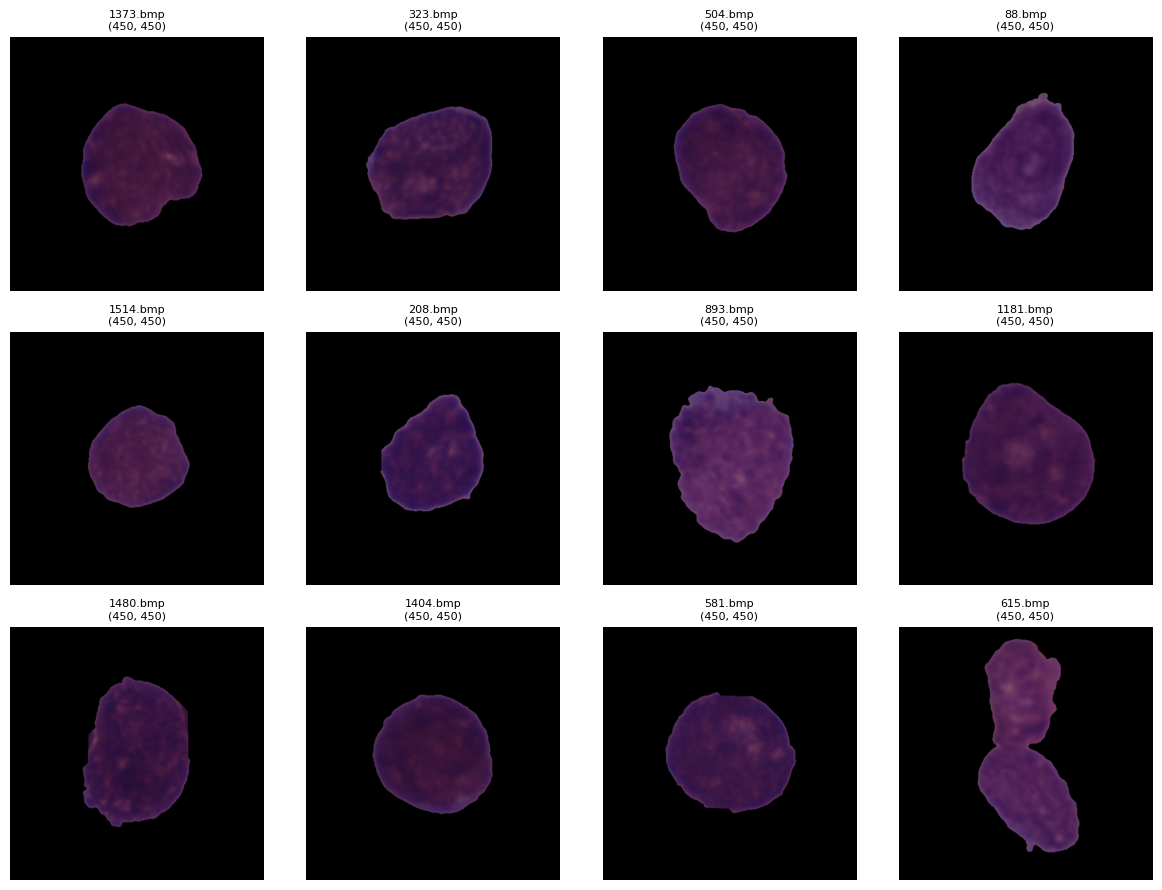

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

sample_files = bmp_files[:12]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, image_path in zip(axes.flat, sample_files):
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(
        f"{image_path.name[:25]}\n{image.size}",
        fontsize=8
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from pathlib import Path
from collections import Counter

root = Path(dataset_path)

pkg_root = next(
    path for path in root.rglob("C-NMC 2019 (PKG)")
    if path.is_dir()
)

train_dir = pkg_root / "C-NMC_training_data"
prelim_dir = pkg_root / "C-NMC_test_prelim_phase_data"
final_dir = pkg_root / "C-NMC_test_final_phase_data"

csv_path = next(pkg_root.rglob("*.csv"))

train_images = sorted(train_dir.rglob("*.bmp"))
prelim_images = sorted(prelim_dir.glob("*.bmp"))
final_images = sorted(final_dir.glob("*.bmp"))

print("Raiz do pacote:", pkg_root)
print("CSV:", csv_path.name)
print()
print("Treinamento:", len(train_images))
print("Teste preliminar:", len(prelim_images))
print("Teste final:", len(final_images))

Raiz do pacote: /content/cnmc/C-NMC 2019 (PKG)
CSV: C-NMC_test_prelim_phase_data_labels.csv

Treinamento: 10661
Teste preliminar: 1867
Teste final: 2586


In [6]:
prelim_labels = pd.read_csv(csv_path)

print("Colunas:", prelim_labels.columns.tolist())
print("Linhas:", len(prelim_labels))

display(prelim_labels.head(10))
print()
print("Distribuição dos rótulos:")
print(prelim_labels["labels"].value_counts().sort_index())

Colunas: ['Patient_ID', 'new_names', 'labels']
Linhas: 1867


,Patient_ID,new_names,labels
0,UID_57_29_1_all.bmp,1.bmp,1
1,UID_57_22_2_all.bmp,2.bmp,1
2,UID_57_31_3_all.bmp,3.bmp,1
3,UID_H49_35_1_hem.bmp,4.bmp,0
4,UID_58_6_13_all.bmp,5.bmp,1
5,UID_57_8_11_all.bmp,6.bmp,1
6,UID_H49_29_2_hem.bmp,7.bmp,0
7,UID_H30_6_2_hem.bmp,8.bmp,0
8,UID_58_2_1_all.bmp,9.bmp,1
9,UID_54_35_3_all.bmp,10.bmp,1



Distribuição dos rótulos:
labels
0     648
1    1219
Name: count, dtype: int64


In [7]:
def extract_subject_id(original_filename, label):
    """
    Exemplos:
    UID_57_29_1_all.bmp  -> ALL_57
    UID_H49_35_1_hem.bmp -> HEM_49
    """
    stem = Path(original_filename).stem
    parts = stem.split("_")

    if len(parts) < 2:
        raise ValueError(
            f"Nome fora do padrão esperado: {original_filename}"
        )

    subject_token = parts[1]

    if int(label) == 1:
        subject_number = subject_token
        return f"ALL_{subject_number}"

    subject_number = subject_token.removeprefix("H")
    return f"HEM_{subject_number}"


training_records = []

for image_path in train_images:
    class_folder = image_path.parent.name.lower()

    if class_folder == "all":
        label = 1
        class_name = "malignant"
    elif class_folder == "hem":
        label = 0
        class_name = "normal"
    else:
        raise ValueError(
            f"Pasta de classe desconhecida: {image_path.parent}"
        )

    fold = next(
        part for part in image_path.parts
        if part.startswith("fold_")
    )

    subject_id = extract_subject_id(
        image_path.name,
        label
    )

    training_records.append({
        "relative_path": str(image_path.relative_to(pkg_root)),
        "original_filename": image_path.name,
        "subject_id": subject_id,
        "label": label,
        "class_name": class_name,
        "official_partition": "training",
        "official_fold": fold,
    })


training_df = pd.DataFrame(training_records)


prelim_records = []

for row in prelim_labels.itertuples(index=False):
    label = int(row.labels)

    image_path = prelim_dir / str(row.new_names)

    prelim_records.append({
        "relative_path": str(image_path.relative_to(pkg_root)),
        "original_filename": str(row.Patient_ID),
        "subject_id": extract_subject_id(
            str(row.Patient_ID),
            label
        ),
        "label": label,
        "class_name": "malignant" if label == 1 else "normal",
        "official_partition": "preliminary_test",
        "official_fold": None,
    })


prelim_df = pd.DataFrame(prelim_records)

metadata_df = pd.concat(
    [training_df, prelim_df],
    ignore_index=True
)

display(metadata_df.head())

print("\nTotal no inventário:", len(metadata_df))

,relative_path,original_filename,subject_id,label,class_name,official_partition,official_fold
0,C-NMC_training_data/fold_0/all/UID_11_10_1_all...,UID_11_10_1_all.bmp,ALL_11,1,malignant,training,fold_0
1,C-NMC_training_data/fold_0/all/UID_11_11_1_all...,UID_11_11_1_all.bmp,ALL_11,1,malignant,training,fold_0
2,C-NMC_training_data/fold_0/all/UID_11_11_2_all...,UID_11_11_2_all.bmp,ALL_11,1,malignant,training,fold_0
3,C-NMC_training_data/fold_0/all/UID_11_11_3_all...,UID_11_11_3_all.bmp,ALL_11,1,malignant,training,fold_0
4,C-NMC_training_data/fold_0/all/UID_11_12_1_all...,UID_11_12_1_all.bmp,ALL_11,1,malignant,training,fold_0



Total no inventário: 12528


In [14]:
print("TREINAMENTO OFICIAL")
print("--------------------")
print("Imagens:", len(training_df))
print("Pacientes:", training_df["subject_id"].nunique())
print()
print("Imagens por classe:")
print(training_df["class_name"].value_counts())
print()
print("Pacientes por classe:")
print(
    training_df
    .groupby("class_name")["subject_id"]
    .nunique()
)

print("\nTESTE PRELIMINAR")
print("----------------")
print("Imagens:", len(prelim_df))
print("Pacientes:", prelim_df["subject_id"].nunique())
print()
print("Imagens por classe:")
print(prelim_df["class_name"].value_counts())
print()
print("Pacientes por classe:")
print(
    prelim_df
    .groupby("class_name")["subject_id"]
    .nunique()
)

TREINAMENTO OFICIAL
--------------------
Imagens: 10661
Pacientes: 73

Imagens por classe:
class_name
malignant    7272
normal       3389
Name: count, dtype: int64

Pacientes por classe:
class_name
malignant    47
normal       26
Name: subject_id, dtype: int64

TESTE PRELIMINAR
----------------
Imagens: 1867
Pacientes: 28

Imagens por classe:
class_name
malignant    1219
normal        648
Name: count, dtype: int64

Pacientes por classe:
class_name
malignant    13
normal       15
Name: subject_id, dtype: int64


In [8]:
subject_fold_counts = (
    training_df
    .groupby("subject_id")["official_fold"]
    .nunique()
)

overlapping_subjects = subject_fold_counts[
    subject_fold_counts > 1
]

print(
    "Pacientes presentes em mais de um fold:",
    len(overlapping_subjects)
)

if len(overlapping_subjects) == 0:
    print("Validação aprovada: folds separados por paciente.")
else:
    display(overlapping_subjects)

Pacientes presentes em mais de um fold: 0
Validação aprovada: folds separados por paciente.


In [9]:
def assign_split(row):
    if row["official_partition"] == "preliminary_test":
        return "test"

    if row["official_fold"] in {"fold_0", "fold_1"}:
        return "train"

    if row["official_fold"] == "fold_2":
        return "validation"

    raise ValueError(f"Partição não reconhecida: {row.to_dict()}")


metadata_df["split"] = metadata_df.apply(
    assign_split,
    axis=1
)

split_summary = (
    metadata_df
    .groupby(["split", "class_name"])
    .agg(
        images=("relative_path", "count"),
        subjects=("subject_id", "nunique")
    )
    .reset_index()
)

display(split_summary)

print("\nTotais por split:")
print(metadata_df["split"].value_counts())

,split,class_name,images,subjects
0,test,malignant,1219,13
1,test,normal,648,15
2,train,malignant,4815,30
3,train,normal,2293,12
4,validation,malignant,2457,17
5,validation,normal,1096,14



Totais por split:
split
train         7108
validation    3553
test          1867
Name: count, dtype: int64


In [10]:
subject_split_counts = (
    metadata_df
    .groupby("subject_id")["split"]
    .nunique()
)

leaked_subjects = subject_split_counts[
    subject_split_counts > 1
]

print(
    "Pacientes presentes em múltiplos splits:",
    len(leaked_subjects)
)

assert len(leaked_subjects) == 0, (
    "Foi detectado vazamento de pacientes!"
)

print("Divisão aprovada: nenhum paciente compartilhado.")

Pacientes presentes em múltiplos splits: 0
Divisão aprovada: nenhum paciente compartilhado.


In [11]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [12]:
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/IT_2026/datasets/cnmc"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

metadata_df.to_csv(
    OUTPUT_DIR / "cnmc_metadata.csv",
    index=False
)

for split_name in ["train", "validation", "test"]:
    split_df = metadata_df[
        metadata_df["split"] == split_name
    ]

    split_df.to_csv(
        OUTPUT_DIR / f"cnmc_{split_name}.csv",
        index=False
    )

print("Arquivos salvos em:", OUTPUT_DIR)

for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(path.name, f"({path.stat().st_size / 1024:.1f} KB)")

Arquivos salvos em: /content/drive/MyDrive/IT_2026/datasets/cnmc
cnmc_metadata.csv (1355.2 KB)
cnmc_test.csv (179.5 KB)
cnmc_train.csv (773.3 KB)
cnmc_validation.csv (402.7 KB)


In [13]:
import json

experiment_config = {
    "dataset": "C-NMC 2019",
    "task": "binary cell image classification",
    "classes": {
        "0": "normal",
        "1": "malignant"
    },
    "training_source": [
        "fold_0",
        "fold_1"
    ],
    "validation_source": [
        "fold_2"
    ],
    "test_source": "preliminary_test",
    "split_unit": "subject",
    "image_size": [
        224,
        224
    ],
    "model": "EfficientNetB0",
    "pretrained_weights": "ImageNet",
    "final_official_test_used": False,
    "reason_final_test_not_used": (
        "Ground-truth labels are not publicly available."
    )
}

config_path = OUTPUT_DIR / "experiment_config.json"

with config_path.open("w", encoding="utf-8") as file:
    json.dump(
        experiment_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print(config_path)

/content/drive/MyDrive/IT_2026/datasets/cnmc/experiment_config.json
